In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
orders         = pd.read_csv('/content/drive/MyDrive/instacart_orders.csv', sep=';')
products       = pd.read_csv('/content/drive/MyDrive/products.csv', sep=';')
departments    = pd.read_csv('/content/drive/MyDrive/departments.csv', sep=';')
aisles         = pd.read_csv('/content/drive/MyDrive/aisles.csv', sep=';')
order_products = pd.read_csv('/content/drive/MyDrive/order_products.csv', sep=';')


Not to mix information about tables, I will call `.info()` on its own line with the name of dataset above it

In [ ]:
# I added the names of datasets in the print, because it was not clear which one was what datasets
print('Orders')
orders.info()

Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [ ]:
print('Products')
products.info()

Products
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [ ]:
print('Deparments')
departments.info()

Deparments
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [ ]:
print('Aisles')
aisles.info()

Aisles
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [ ]:
# Because of having a lot of rows, we need show_counts=True (If we do not it will not show non null counts)
print('Order products')
order_products.info(show_counts=True)

Order products
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


**First impressions:**
There are 3 columns with missing data - `orders.['days_since_prior_order']`, `products['product_name']`, and `order_products['add_to_cart_order']`. In next steps, I will fill them wisely.
No fix is needed for datatype. `days_since_prior_order` and `add_to_cart_order` are float because of missing values, I will come back to them after handling with missing values.

## Step 1. Duplicate values, identifying them and deciding what to do

### Dublicates in `orders`

In [ ]:
# Checking for duplicated orders
dublicated_orders = orders.duplicated().sum()
print(f'Total dublicated orders: {dublicated_orders}')

Total dublicated orders: 15


In [ ]:
# Check if all dublicates share the same day and hour. Wednesday at 2:00 AM
wed_2am_orders = orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)]
wed_2am_dublicates = wed_2am_orders.duplicated().sum()

print(f'Dublicated orders on Wednesday 2:00 AM: {wed_2am_dublicates}')

Dublicated orders on Wednesday 2:00 AM: 15


We can see that all the duplicate orders occurred on Wednesday at 2:00 am. Most probably this is a systemic problem, it is less probability that a customer place the identical order twice. As they are the excat copies of existing data, I am dropping them

In [ ]:
orders = orders.drop_duplicates()

In [ ]:
# double check
orders.duplicated().sum()

np.int64(0)

In [ ]:
# Double check for duplicate order IDs(a duplicate ID with different values can be bigger issue than a duplicate row)
orders['order_id'].duplicated().sum()

np.int64(0)

### `products` data frame
Now, we are going to check for dublicates in 'products'. We need to find not only fully dublicates, but also dublicate product IDs and dublicate product names ( because of case sensitivity)

In [ ]:
# fully duplicate rows
products.duplicated().sum()

np.int64(0)

In [ ]:
# Duplicate product IDs
products['product_id'].duplicated().sum()

np.int64(0)

In [ ]:
# Duplicate product names (convert names to lowercase so case differences does not hide the match)
products['product_name'].str.lower().duplicated().sum()

np.int64(1361)

In [ ]:
# Recheck duplicate product names where product name really exists (the check above counts every missing names as a dublicate of every other)
# As multiple missing names are not real duplicated products we must check duplicates for non missing products
notna_products = products[products['product_name'].notna()]
notna_products['product_name'].str.lower().duplicated().sum()

np.int64(104)

**Analysis of Product Duplicates:**
As we checked product dublicates, there are no duplicate prodcut_id. As we checked for lowercase dublicate product names excluding 'NaN' values, we found 104 duplicate product names. For now, because of the possibility of their difference in departments and IDs (maybe different sizes or different brands of the same product), I will not drop them.

### Dublicates in `departments`

In [ ]:
# Fully duplicated rows in deparments
departments.duplicated().sum()

np.int64(0)

In [ ]:
# Duplicate Deparment IDs
departments['department_id'].duplicated().sum()

np.int64(0)

 Nothing to fix here.

### Dublicates in `aisles`

In [ ]:
# Fully duplicate rows in aisles
aisles.duplicated().sum()

np.int64(0)

In [ ]:
# Duplicate aisley_IDs
aisles['aisle_id'].duplicated().sum()

np.int64(0)

Small, clean table. Nothing to fix

### Dublicates in `order_products`

In [ ]:
# Fully duplicate rows
order_products.duplicated().sum()

np.int64(0)

In [ ]:
# It is a tricky dublicate: the exact same product logged twice inside the exact same order
order_products.duplicated(subset=['order_id','product_id']).sum()

np.int64(0)

**Analysis of Order-Products Duplicates:**
Checking for fully duplicated rows resulted 0. I also checked for "tricky" duplicates where the same `product_id` is logged multiple times under the same `order_id`, so it also was clean. No removal is needed

## Step 2. Missing values, finding them and deciding what to do


###  Missing values in `products`

In [ ]:
products.isna().sum()

,0
product_id,0
product_name,1258
aisle_id,0
department_id,0


In [ ]:
# are the missing product names all coming from the same aisle?
missing_products = products[products['product_name'].isna()]
print('Aisle IDs for missing product names: ',missing_products['aisle_id'].unique())

Aisle IDs for missing product names:  [100]


In [ ]:
# and the same deparment?
print( 'Deparment IDs for missing product names:',missing_products['department_id'].unique())

Deparment IDs for missing product names: [21]


In [ ]:
# What do this aisle and deparment stand for?
aisle_name = aisles[aisles['aisle_id'] == 100]['aisle'].values
department_name = departments[departments['department_id'] == 21]['department'].values

print(f'Aisle 100 is {aisle_name}')
print(f'department 21 is {department_name}')

Aisle 100 is ['missing']
department 21 is ['missing']


Every missing product name is assosiated with aisle 100 and deparment 21. So they are Instacart's own missing (unnown) placeholders. It is clear that I can not guess the real name of product so instead of dropping that real order history (there can be product_id's tied to that product) I will fill them with 'Unnown'.

In [ ]:
products['product_name'] = products['product_name'].fillna('Unknown')

#Checking
products['product_name'].isna().sum()

np.int64(0)

###  Missing values in `orders`
Now, I am going to analyze the missing values in `orders` table, specifically in the `days_since_prior_order` column.

In [ ]:
print('missing values in each column:',orders.isna().sum())

missing values in each column: order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [ ]:
#Maybe missing values are first orders
first_order_check = orders[(orders['days_since_prior_order'].isna()) & (orders['order_number'] == 1)]
print(f'count if the missing values are because of the first order {len(first_order_check)}')

count if the missing values are because of the first order 28817


In [ ]:
# are there any missing values that are NOT a customer's first order?
total_missing = orders['days_since_prior_order'].isna().sum()
first_order_missing = len(first_order_check)

print('Total missing:', total_missing)
print('Missing and first orders:', first_order_missing)

Total missing: 28817
Missing and first orders: 28817


**Analysis of Missing Values in 'orders':**
As we see there exist missing values in 'days_since_prior_order' column. Then, we searched for 'order_number' == 1 to see if they were because of being first order which logically does not have prior order. It turned out that every missing value is because of being first order. I will not change them. As there is no prevoius order I could write '0' for them but I did not because it represents ordered again same day.

### Missing values in `order_products`
Now, I verify the `add_to_cart_order` column in the `order_products` dataset. This column records the sequence in which items were added to the cart.

In [ ]:
print('Missing values in add_to_cart_order:', order_products['add_to_cart_order'].isna().sum())

Missing values in add_to_cart_order: 836


In [ ]:
# let's see the distribution of this column:
print('min:', order_products['add_to_cart_order'].min())
print('max:', order_products['add_to_cart_order'].max())

min: 1.0
max: 64.0


In [ ]:
# Let's ave all order IDs with at least one missing value in 'add_to_cart_order'
missing_order_ids = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
print(f"Number of unique orders that has null in 'add_to_cart_order': {len(missing_order_ids)}")

Number of unique orders that has null in 'add_to_cart_order': 70


In [ ]:
# Do all these orders are large? (more than 64 products)
# I am going to check the count of products for each of the orders that contains missing 'add_to_crt_order'.
order_having_missing = order_products[order_products['order_id'].isin(missing_order_ids)]
print(order_having_missing)         # For finding next step easily (seeing visually)
orders_product_counts = order_having_missing.groupby('order_id')['product_id'].count()
print(orders_product_counts)        # To see the result visually

# Let's check is minimum count for these orders is greater than 64
print('Do all orders with missing values have more than 64 products?', orders_product_counts.min() > 64)
print(f"Minimum number of products in these orders: {orders_product_counts.min()}")

         order_id  product_id  add_to_cart_order  reordered
267       2094761       31469               57.0          1
737       2449164        5068                NaN          0
1742      2997021        4920               37.0          0
3463       871281       40063               61.0          1
3535       171934       36397                7.0          0
...           ...         ...                ...        ...
4543519   2621907       32018               28.0          1
4544672    102236       34688               49.0          0
4544708   2256933       41544               21.0          0
4544771    180546       12741               46.0          1
4544810   2136777       20072               10.0          0

[5316 rows x 4 columns]
order_id
9310        65
61355      127
102236      95
129627      69
165801      70
          ... 
2999801     70
3125735     86
3308010    115
3347453     71
3383594     69
Name: product_id, Length: 70, dtype: int64
Do all orders with missing values have

In [ ]:
# fill with placeholder (999) and convert the column back to int type,
# since a whole "position in cart" number was float bacause of nulls, now there are no nulls.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype(int)

# Let's check if data type changed and there is no missing values now
print("Count of missing values in 'add_to_cart_order':", order_products['add_to_cart_order'].isna().sum())
print("Type of 'add_to_cart_order':", order_products['add_to_cart_order'].dtype)

Count of missing values in 'add_to_cart_order': 0
Type of 'add_to_cart_order': int64


**Data Cleaning Note:**
In `order_products`, we found 836 missing values in the `add_to_cart_order` column. Then we showed these missing values contains more than 64 products (large orders). It means values over 64th item were not recorded so We replaced missings with '999' to make our dataframe usable, and changed data type to 'int'.

# [A] Easy -  Getting a First Feel for the Data

### [A1] Sanity-checking `order_hour_of_day` and `order_dow`
Just for being comfortable to work, I want to make sure they only contain values in ranges- hours 0 to 23, days 0 to 6. If there's an anormal value. I do not want them to cause a problem when making chart.

In [ ]:
print('Order hour of day range:', orders['order_hour_of_day'].min(), '-' , orders['order_hour_of_day'].max())

Order hour of day range: 0 - 23


In [ ]:
#Just for being sure:
hour_check = orders[(orders['order_hour_of_day'] < 0) | (orders['order_hour_of_day'] > 23)]
dow_check = orders[(orders['order_dow'] < 0) | (orders['order_dow'] > 6)]

print('Evertthing is okay -', len(hour_check) == 0)
print('Everything is okay -', len(dow_check) == 0)

Evertthing is okay - True
Everything is okay - True


Perfect, I can move on and create the plots without worrying that a problematic value will cause a problem.

 [A2] What hours are busiest for ordering?
Let's create a bar chart that show the distribution of orders by hour of day. As a result, we will find peak times which is useful for delivery stafs.

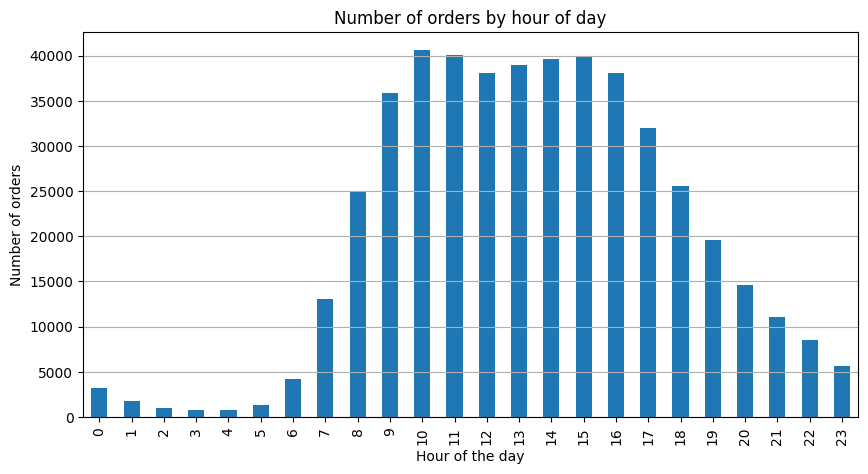

In [ ]:
import matplotlib.pyplot as plt

orders['order_hour_of_day'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5))
plt.title('Number of orders by hour of day')
plt.xlabel('Hour of the day')
plt.ylabel('Number of orders')
plt.grid(axis = 'y')
plt.show()

As it is clear from chart, the poorest time is after midnight until 6am. After 6am orders are rapidly increasing until 10am (the most). Then until 4pm the number of orders is between 35000 and 40000. After 4pm orders are decreasing. So people mostly shop from 9am to 4pm, not too early in the morning or late at night.

### [A3] What day of the week are the busiest order days?

Same idea, but by day of the week this time.

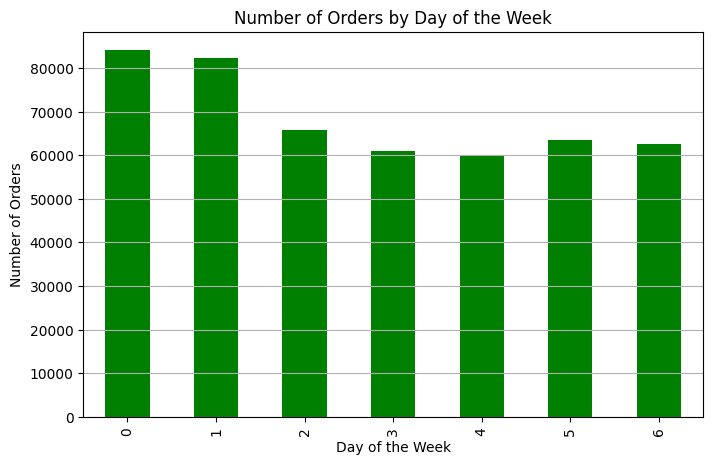

In [ ]:
orders['order_dow'].value_counts().sort_index().plot(kind='bar', figsize=(8, 5), color='green')

plt.title('Number of Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.grid(axis='y')
plt.show()

day 0 and day 1 are busier than the rest. From 2 to 6 are approximately same ranging between about 60000 - 66000. Since the data does not tell us which number is which day, I can guess that 0 and 1 are weekend and others are weekdays but I can not prove for now.

### [A4] How long do customers wait before ordering again?
As `Days_since_prior_order` is a continous number, column is analyzed using a histogram to understand how fruqiently reordering changes.

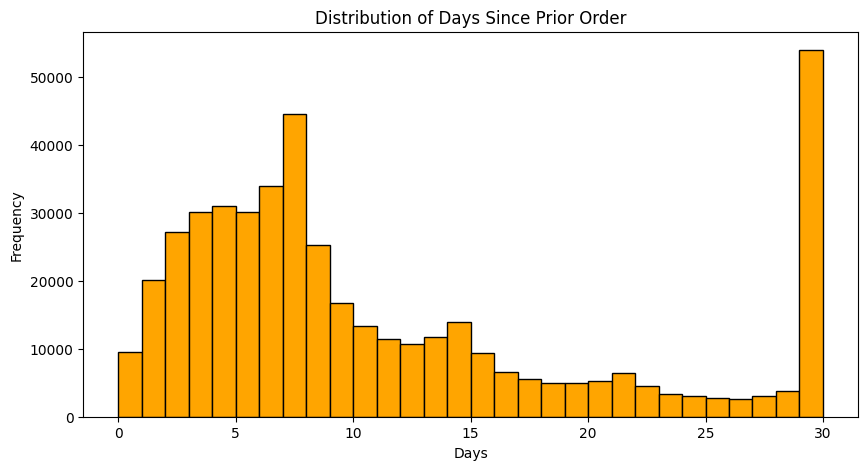

Min waiting time: 0.0
Max waiting time: 30.0


In [ ]:
orders['days_since_prior_order'].plot(kind='hist', bins=30, figsize=(10,5),  color='orange', edgecolor='black')

plt.title('Distribution of Days Since Prior Order')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

print("Min waiting time:", orders['days_since_prior_order'].min())
print("Max waiting time:", orders['days_since_prior_order'].max())
#Because of 0-30 I used bins=30

Some customers order again the same day (minimum is 0). In 30, it does seem as a real behavioral limit, most probably they showed all days more than 30 as 30. There are sudden increases right at 7, 14, and 21, and 30 which confirms that people shops weekly (most on the o and 1 days as we saw from previous chart) or monthly.

 <font color="orange"> Histogram, min və max göstərilib. İzahınız da yaxşıdır. Amma “How long do customers wait before ordering again?” sualında tipik gözləmə müddətini daha dəqiq göstərmək üçün median və ya mode da əlavə etmək yaxşı olardı. Təkcə min/max insanların adətən neçə gün gözlədiyini tam göstərmir. </font>

# [B] Medium

### [B1] Wednesday vs. Saturday - does shopping time change on weekends?

For comparing shopping behavior, I will plot graph of hourly distributions on the same area for both so it's easy to see how a weekday and a weekend day differ

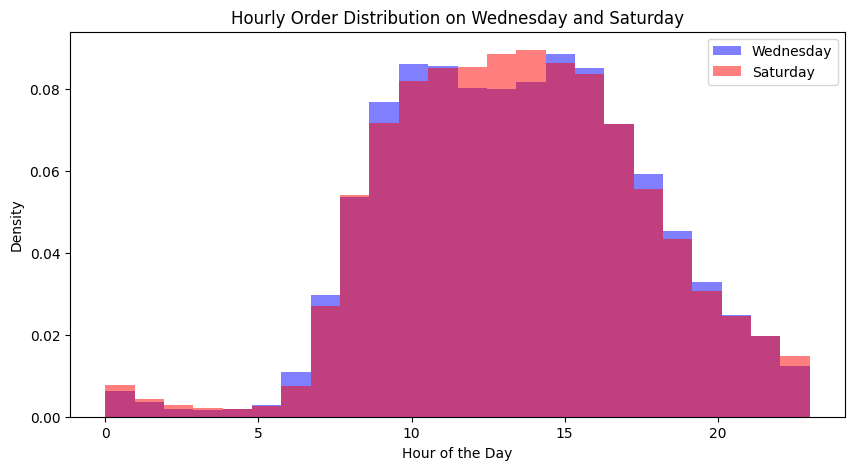

In [ ]:
# comparing Wednesday (day 3) and Saturday (day 6)
wednesday = orders[orders['order_dow'] == 3]['order_hour_of_day']
saturday = orders[orders['order_dow'] == 6]['order_hour_of_day']

plt.figure(figsize=(10, 5))
plt.hist(wednesday, bins=24, alpha=0.5 ,label='Wednesday', color='blue', density=True)  #alpha is transparency. If it was not exist or it was one we could not see the overlapping seperatelyfor example if a column is fully red we do not now how much blue exist in it
plt.hist(saturday, bins=24, alpha=0.5, label='Saturday', color='red', density=True)     #density here makes y axis overal 1 (100%)

plt.title('Hourly Order Distribution on Wednesday and Saturday')
plt.xlabel('Hour of the Day')
plt.ylabel('Density')
plt.legend()
plt.show()

**Analysis of shopping patterns:** Purple shows overlapping, pink is saturday and blue is wednesday. Wednesday peaks earlier in morning (except 7-8)until 11am, while Satuday's peak is later, around 12-14. After that, from about 15:00, Wednesday is little bit higher than saturday or they are same until 22:00. In late hour Saturday is more than wednesday and the reason for that I assume is that in saturdays people does not need to sleep early because they do not have work in sunday, but wednesday most people sleep early to reach the work thursday.

### [B2] How many orders does a typical customer place?

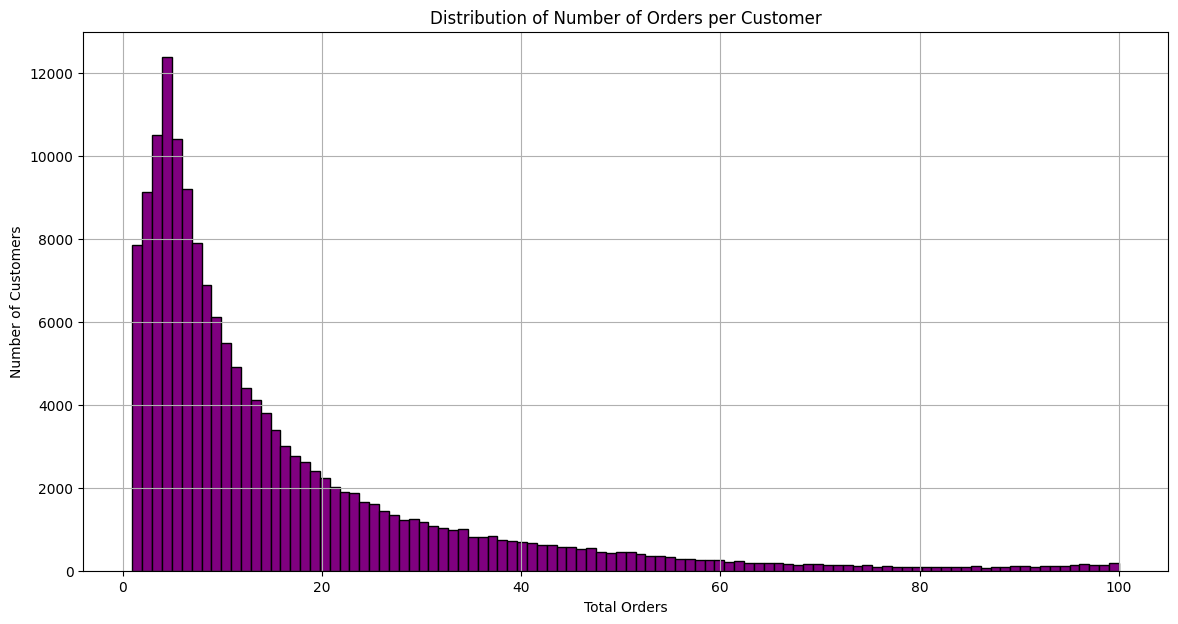

,order_number
count,157437.000000
mean,15.577571
std,17.215517
min,1.000000
25%,4.000000
50%,9.000000
75%,20.000000
max,100.000000


In [ ]:
# Count how many orders each user has placed
# order_number: the number of times this customer has placed an order - so we should use max to find order number
orders_per_customer = orders.groupby('user_id')['order_number'].max()

# Plot the distribution
orders_per_customer.hist(bins=100, figsize=(14, 7), color='purple', edgecolor='black')
plt.title('Distribution of Number of Orders per Customer')
plt.xlabel('Total Orders')
plt.ylabel('Number of Customers')
plt.show()

orders_per_customer.describe()  #for detailed analyze

It is rigt skewed. Biggest group of customers placed 4 orders. Then counts dicrease rapidly, by 20 orders there are only about 2100 customers left, and after 40 it is a long thin tail.
There is a small increase in 100 and most probably the orders more than 100 counted as 100 (similar to the 30 day in [A4]).

### Which 20 products get ordered the most?

In [ ]:
# reset_index() turns index back into a normal column we use it not to face a problem when merge
top_products = order_products['product_id'].value_counts().head(20).reset_index()
top_products.columns = ['product_id', 'count']

# Merging with products table for names
top_products_names = top_products.merge(products, on='product_id')[['product_id', 'product_name', 'count']]
print(top_products_names)

    product_id              product_name  count
0        24852                    Banana  66050
1        13176    Bag of Organic Bananas  53297
2        21137      Organic Strawberries  37039
3        21903      Organic Baby Spinach  33971
4        47209      Organic Hass Avocado  29773
5        47766           Organic Avocado  24689
6        47626               Large Lemon  21495
7        16797              Strawberries  20018
8        26209                     Limes  19690
9        27845        Organic Whole Milk  19600
10       27966       Organic Raspberries  19197
11       22935      Organic Yellow Onion  15898
12       24964            Organic Garlic  15292
13       45007          Organic Zucchini  14584
14       39275       Organic Blueberries  13879
15       49683            Cucumber Kirby  13675
16       28204        Organic Fuji Apple  12544
17        5876             Organic Lemon  12232
18        8277  Apple Honeycrisp Organic  11993
19       40706    Organic Grape Tomatoes

These are almast what I was expecting. They are everyday orders like bananas, berries, milk, eggs and etc. They should be bought weekly or even more rapidly because they can rot.

# [C] Hard - Reorder behaviour

### [C1] How big is a typical order?

I want to know how many items usually exist in one order, and what that distribution looks like and is it mostly small orders with a few huge ones or what?

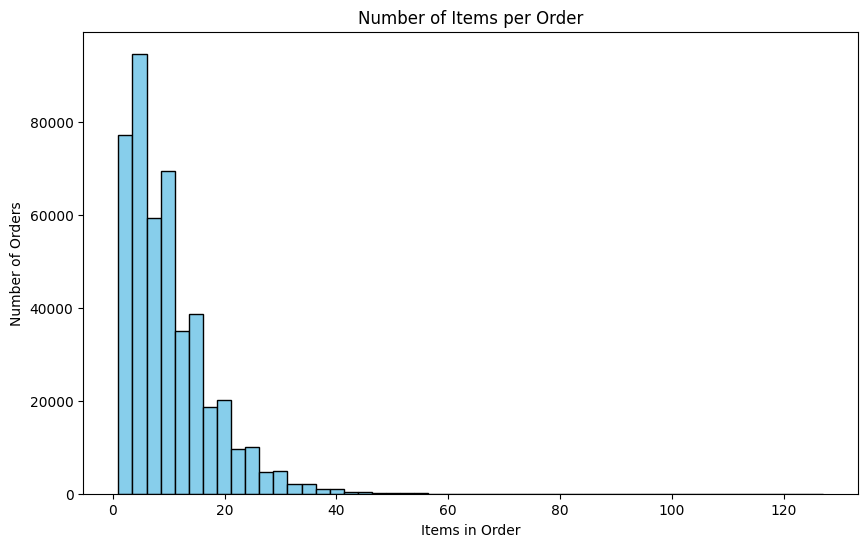

,product_id
count,450046.000000
mean,10.098983
std,7.540206
min,1.000000
25%,5.000000
50%,8.000000
75%,14.000000
max,127.000000


In [ ]:
# group by order_id and count how many rows (items) each order has
items_per_order = order_products.groupby('order_id')['product_id'].count()

items_per_order.plot(kind='hist', bins=50, figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Number of Items per Order')
plt.xlabel('Items in Order')
plt.ylabel('Number of Orders')
plt.show()

items_per_order.describe()

Same right skewed (It is also clear from mean and median difference) graph I saw in [B2]: most orders are small, and there is a long tail of much bigger orders

### [C2]  Which 20 products do people reorder the most?

This is different from [B3], I'm not asking what's ordered most overall, I'm asking what specifically gets *reordered* (reordered == 1) most often.

In [ ]:
# keep only the rows where reordered == 1, then just count how many times each product_id appears among those, that is the reorder count
reordered_items = order_products[order_products['reordered'] == 1]

top_reordered = reordered_items['product_id'].value_counts().head(20).reset_index()
top_reordered.columns = ['product_id', 'count']

top_reordered_names = top_reordered.merge(products, on='product_id')[['product_id', 'product_name', 'count']]
print(top_reordered_names)

    product_id              product_name  count
0        24852                    Banana  55763
1        13176    Bag of Organic Bananas  44450
2        21137      Organic Strawberries  28639
3        21903      Organic Baby Spinach  26233
4        47209      Organic Hass Avocado  23629
5        47766           Organic Avocado  18743
6        27845        Organic Whole Milk  16251
7        47626               Large Lemon  15044
8        27966       Organic Raspberries  14748
9        16797              Strawberries  13945
10       26209                     Limes  13327
11       22935      Organic Yellow Onion  11145
12       24964            Organic Garlic  10411
13       45007          Organic Zucchini  10076
14       49683            Cucumber Kirby   9538
15       28204        Organic Fuji Apple   8989
16        8277  Apple Honeycrisp Organic   8836
17       39275       Organic Blueberries   8799
18        5876             Organic Lemon   8412
19       49235       Organic Half & Half

This list looks like [B3] list, which is normal, the most popular products overall are also the ones that people most likely to buy again and again.

### [C3] For each product, what share of its orders are repeat orders?

Instead of counting *raw* reorders like [C2], here I want the *rate*,nout of everyone who ordered this product, what fraction had ordered it before?

In [ ]:
# reordered is a 0 1 column, so the mean of it = the share of rows that are 1 meaning reorders
# .agg(['mean', 'count']) gets  'mean', 'count' ( times that product was ordered in total)

reorder_share = (order_products.groupby('product_id')['reordered'].agg(['mean', 'count']).rename(columns={'mean': 'reorder_share', 'count': 'times_ordered'}))

reorder_share = reorder_share.merge(products[['product_id', 'product_name']], on='product_id')
reorder_share = reorder_share[['product_id', 'product_name', 'reorder_share', 'times_ordered']]

reorder_share.sort_values('reorder_share', ascending=False).head(20)

,product_id,product_name,reorder_share,times_ordered
28108,30644,Organic French Roast,1.0,2
7340,8054,Bissli Smokey Wheat Snacks,1.0,1
28114,30650,Mushroom Lover's Veggie Burgers,1.0,2
41002,44747,Frozen Organic Blackberries,1.0,1
40998,44743,Real Zero Cola,1.0,2
32921,35897,Ham Hock,1.0,1
32861,35834,Bulgarian Organic Yogurt,1.0,2
2684,2939,Cheddar Crunchin' Crackers,1.0,7
20357,22209,Temples Earl Gray Strong Tea,1.0,2
20361,22213,2% Reduced Fat Chocolate Milk,1.0,2


But there is one meaningful point here - a product that ordered only 1 or 2 times in the whole dataset can show reorder share as 0 or 100 percent, which is while correct but not very meaningful. So, I will again do ranking with only looking at products with reasonable minimum number of orders


In [ ]:
# I only kept products ordered at least 50 times
reorder_share[reorder_share['times_ordered'] >= 50].sort_values('reorder_share', ascending=False).head(20)

,product_id,product_name,reorder_share,times_ordered
44045,48041,DanActive Vanilla Probiotic Dairy Drink,0.907692,65
30242,32978,Lemon Lime Seltzer,0.893939,66
36458,39782,Organic Raspberry Mate Energy Drink,0.892308,65
15984,17469,Lo-Carb Energy Drink,0.888889,63
22943,25000,Whole Wheat Multigrain Pop Cakes,0.886792,53
44092,48095,Purified Water- 9.5pH+,0.877193,57
8483,9292,Half And Half Ultra Pasteurized,0.876574,397
2450,2677,Yerba Mate Sparkling Classic Gold,0.871345,171
43292,47231,Ultra-Purified Water,0.868293,205
1046,1157,Wheat Sandwich Bread,0.863946,147


### [C4] For each customer, how much of their shopping is usual?

Instead of a rate per product, it's a rate per customer: out of everything a customer ever ordered, what percent(fraction) of it is something they already ordered before?

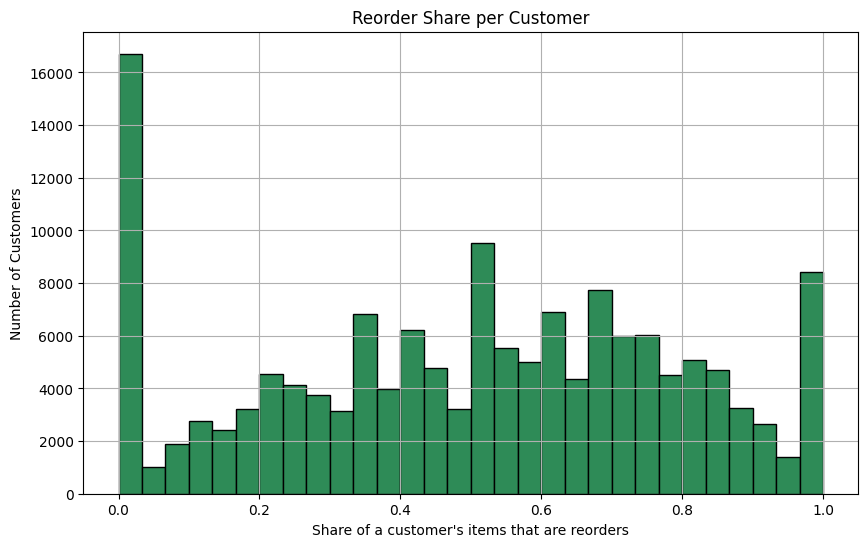

,reordered
count,149626.000000
mean,0.494853
std,0.292685
min,0.000000
25%,0.272727
50%,0.500000
75%,0.724138
max,1.000000


In [ ]:
# order_products doesn't have user_id, only order_id, so first merge in user_id from orders, then group by user_id and take the mean of reordered,
# same as C3 but per customer instead of per product

order_products_users = order_products.merge(orders[['order_id', 'user_id']], on='order_id')

customer_reorder_share = order_products_users.groupby('user_id')['reordered'].mean()

customer_reorder_share.hist(bins=30, figsize=(10, 6), color='seagreen', edgecolor='black')
plt.title('Reorder Share per Customer')
plt.xlabel("Share of a customer's items that are reorders")
plt.ylabel('Number of Customers')
plt.show()

customer_reorder_share.describe()

Someone close to 0 is trying new things every trip, someone close to 1 is buying almost the exact same list every time.

### [C5] Which 20 products do people grab first?

I only want the item that landed in position 1 of the cart for each order: add_to_cart_order == 1. I filled the missing values in that column with 999 instead of 1, so 836 prolematic rows can not accidentally fall here first item ranking. So there is no need to any filter

In [ ]:
# add_to_cart_order == 1 means "this was the first item placed in the cart"
# filter to just those rows, then count which product_id appears most often
first_in_cart = order_products[order_products['add_to_cart_order'] == 1]

top_first = first_in_cart['product_id'].value_counts().head(20).reset_index()
top_first.columns = ['product_id', 'count']

top_first_names = top_first.merge(products, on='product_id')[['product_id', 'product_name', 'count']]
print(top_first_names)

    product_id                 product_name  count
0        24852                       Banana  15562
1        13176       Bag of Organic Bananas  11026
2        27845           Organic Whole Milk   4363
3        21137         Organic Strawberries   3946
4        47209         Organic Hass Avocado   3390
5        21903         Organic Baby Spinach   3336
6        47766              Organic Avocado   3044
7        19660                 Spring Water   2336
8        16797                 Strawberries   2308
9        27966          Organic Raspberries   2024
10       44632   Sparkling Water Grapefruit   1914
11       49235          Organic Half & Half   1797
12       47626                  Large Lemon   1737
13         196                         Soda   1733
14       38689     Organic Reduced Fat Milk   1397
15       26209                        Limes   1370
16       12341                Hass Avocados   1340
17        5785  Organic Reduced Fat 2% Milk   1310
18       27086                 

These are products that they are most sure they need, because they are something that is used rapidly and they can not be hold for long time.

### Extra: Which departments actually drive the most orders?

[B3] shows the top individual products. Department shows which broad categories of the store people rely on most

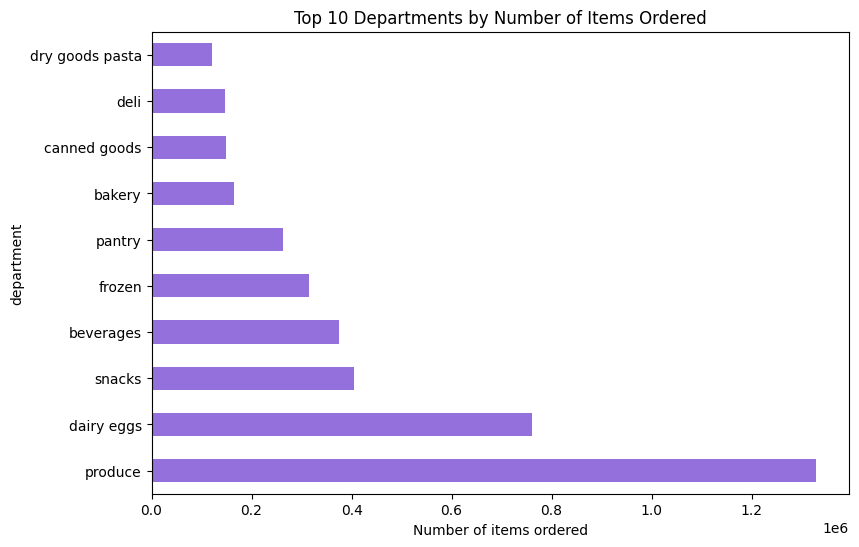

In [ ]:
# order_products only has product_id, two merges to reach the department name:
# order_products -then- products (getting department_id) -then-  departments (getting the actual name)
order_products_full = order_products.merge(products[['product_id', 'department_id']], on='product_id', how='left').merge(departments, on='department_id', how='left')

# now every row has a department name, so counting rows per department
# is same with value_counts() on that column
top_departments = order_products_full['department'].value_counts().head(10)

# horizontal bars so long department names are readable
top_departments.plot(kind='barh', figsize=(9, 6), color='mediumpurple')
plt.title('Top 10 Departments by Number of Items Ordered')
plt.xlabel('Number of items ordered')
plt.show()

**Produce is by far the #1 department**, with around 1.3 million items ordered nearly double the 'dairy eggs' spot. 'Dairy eggs' comes second, and then there's a noticeable drop to 'snacks' and beverages. This is expected: produce and dairy are the items people buy on almost every trip because they finish fast and not possible to keep long.
To be honest, the gap between produce and others is bigger than I expected.

In [ ]:
# Export for visualiation in Tableau:
orders.to_csv('cleaned_orders.csv', index=False)
products.to_csv('cleaned_products.csv', index=False)
order_products.to_csv('cleaned_order_products.csv', index=False)
aisles.to_csv('cleaned_aisles.csv', index=False)
departments.to_csv('cleaned_departments.csv', index=False)

In [ ]:
drive_path = '/content/drive/MyDrive/'

orders.to_csv(drive_path + 'cleaned_orders.csv', index=False)
products.to_csv(drive_path + 'cleaned_products.csv', index=False)
order_products.to_csv(drive_path + 'cleaned_order_products.csv', index=False)
aisles.to_csv(drive_path + 'cleaned_aisles.csv', index=False)
departments.to_csv(drive_path + 'cleaned_departments.csv', index=False)

In [ ]:
len(order_products) / order_products['order_id'].nunique()

10.098983215049127